## Assignment 7

This assignment encourages you to explore on your own and learn how to use the scikit-learn API for common ML tasks. Some of the material was covered in brief towards the end of the regression lecture and some functions and methods were mentioned in the two uploaded videos on ROC and AUC.

Read the first 6 sections of [Chapter 5](https://jakevdp.github.io/PythonDataScienceHandbook/05.00-machine-learning.html) of the [Data science handbook](https://jakevdp.github.io/PythonDataScienceHandbook/). These are well written and provide a nice overview of many important concepts. There are also several nice code samples that are worth studying. You will also find the [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html) very handy to skim or refer.

1. Consider the pendulum data provided in the `data/pendulum.txt` file and used in our regression material. Use `sklearn.model_selection.train_test_split` to split the data into 75% training data and 25% test data.  Look at the [sklearn user guide](https://scikit-learn.org/stable/user_guide.html)  to read more about the `train_test_split` functionality. Now use the training data to determine the best fit coefficients using a linear regression (this was done at the end in the regression notebook I shared). Recall that we had a linear model for $l$ vs. $t^2$. Then use the trained model to fit the test data. Calculate the error on the test data using the `model.score` method where `model` is your `LinearRegression` model. Read the documentation of `model.score` to understand what it is computing.

In [60]:
import sklearn as sk
import numpy as np

pendulum_data = np.loadtxt("data/pendulum.txt", unpack=True)
pendulum_x_train, pendulum_x_test, pendulum_y_train, pendulum_y_test = sk.model_selection.train_test_split(pendulum_data[0], pendulum_data[1], test_size=0.25, random_state=42)

model = sk.linear_model.LinearRegression()
model.fit(pendulum_x_train.reshape(-1, 1), pendulum_y_train)

#Best fit coefficients
print("Coefficients:", model.coef_)
print("Intercept", model.intercept_)

#Using the trained model to predict the test set
pendulum_y_pred = model.predict(pendulum_x_test.reshape(-1, 1))
print("Predicted values:", pendulum_y_pred)

#Calulate the error of the model using model score
print(model.score(pendulum_x_test.reshape(-1, 1), pendulum_y_test))

Coefficients: [1.44683668]
Intercept 0.6883053643919641
Predicted values: [1.4117237  1.1512931  1.62874921 1.84577471 0.83298903 1.20916657
 1.39725534 1.77343287 0.9776727  1.46959717 2.00492674 1.33938187
 1.64321757 2.07726858 1.00660943 0.8908625  1.09341963 1.2381033
 1.541939   1.73002777 1.88917981 1.83130634 1.93258491]
0.9732741349608606


2. Convert the pendulum data into a `pandas.DataFrame` object with suitable columns for length `l`,  and the square of the time period, `tsq`. Read the [data as table](https://jakevdp.github.io/PythonDataScienceHandbook/05.02-introducing-scikit-learn.html#Data-as-table) section to see how to use the data frame as your input features matrix and target array. Use this to once again fit a linear model between the length and square of the time period. Note that this is a rather trivial exercise but this should show you how to deal with data frames and use them in scikit-learn.

In [61]:
import pandas as pd

df_pendulum = pd.DataFrame({
    "l": pendulum_data[0],
    "tsq": pendulum_data[1]
})

df_pendulum.head()

X = df_pendulum[["l"]]
y = df_pendulum["tsq"]

model = sk.linear_model.LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept", model.intercept_)
print("model score:", model.score(X, y))

Coefficients: [1.44567376]
Intercept 0.6906812440493341
model score: 0.9760965869123868


3. Now just to see how you can compute a cross-validation score, use `sklearn.model_selection.cross_val_score` on the first problem. Use $k=4$ for this, i.e. use the keyword argument `cv=4`. To understand this better, see the [cross-validation user documentation from scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html).  Note that this should not take you more than 3-4 lines of code after you solve the previous problem.

In [62]:
scores = sk.model_selection.cross_val_score(model, X, y, cv=4)
print(scores)

[-0.09198853  0.41427628  0.51323199 -2.49606218]


4. Read the [section on feature engineering](https://jakevdp.github.io/PythonDataScienceHandbook/05.04-feature-engineering.html) from the Python data science handbook. Pay particular attention to the example where the `PolynomialFeatures` preprocessor was highlighted. Use this to redo the linear model for the pendulum data where you use the original feature as $t$ and not the square of the values. Recall, that originally we had taken $t^2$ as the dependent/response variable ($Y$), and the length as the independent/feature variable $x$. Now, reverse this and treat the length as the target variable and the time period as the input feature.  Then use a `PolynomialFeatures` preprocessor to calculate the new polynomial features with polynomial order 2. Then use this new data to fit the model and look at the new coefficients. Evaluate the error in the model as in the first problem. 

In [63]:
import numpy as np
import sklearn as sk

pendulum_data = np.loadtxt("data/pendulum.txt", unpack=True)
y = pendulum_data[0]
X = np.sqrt(pendulum_data[1])

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X.reshape(-1, 1), y, test_size=0.25, random_state=42
)

#Create polynomial features
polynomial_features = sk.preprocessing.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = polynomial_features.fit_transform(X_train)
X_test_poly = polynomial_features.transform(X_test)

#Fit linear regression on transformed features
model = sk.linear_model.LinearRegression()
model.fit(X_train_poly, y_train)

print('Features:', polynomial_features.get_feature_names_out(["t"]))
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

#Prediction and score
y_pred = model.predict(X_test_poly)
print('Predicted lengths:', y_pred)
print('Test score R^2:', model.score(X_test_poly, y_test))


Features: ['t' 't^2']
Coefficients: [-3.07939166  1.99526423]
Intercept: 1.3061149934485417
Predicted lengths: [0.50240211 0.34174967 0.68906451 0.79138189 0.12491815 0.38858943
 0.50696837 0.71819795 0.18042953 0.5092943  0.91627071 0.45229714
 0.65506147 0.94771505 0.23332984 0.15847505 0.29459914 0.36747877
 0.63100085 0.70431884 0.79884923 0.76572937 0.90550546]
Test score R^2: 0.9914205004860239


5. Use the `sklearn.pipeline.make_pipeline` function documented [here](https://jakevdp.github.io/PythonDataScienceHandbook/05.04-feature-engineering.html#Feature-Pipelines) to implement the previous problem. Use the `PolynomialFeature` and `LinearRegression` classess to make the pipeline.  Note that this is again just a few lines of code.

In [64]:
model = sk.pipeline.make_pipeline(polynomial_features, sk.linear_model.LinearRegression())

model.fit(X_train, y_train)
print('Predicted lengths:', model.predict(X_test))
print('Test score R^2:', model.score(X_test, y_test))

Predicted lengths: [0.50240211 0.34174967 0.68906451 0.79138189 0.12491815 0.38858943
 0.50696837 0.71819795 0.18042953 0.5092943  0.91627071 0.45229714
 0.65506147 0.94771505 0.23332984 0.15847505 0.29459914 0.36747877
 0.63100085 0.70431884 0.79884923 0.76572937 0.90550546]
Test score R^2: 0.9914205004860239


6. Consider the data in the file `student_performance.csv` with categorical features. First study the dataset (use a spreadsheet to view the data for example) and clean up the column names with spaces and replace them with underscores using pandas (and not the spreadsheet application!). For example `"math score"` should be `"math_score"`. You may also rename some long column names suitably.  Our plan is to see if the math scores can be well predicted with a linear regression model using all the available data (excluding the math scores of course). Clearly this is multiple linear regression with categorical variables given the nature of the data. To do this, first use the `pd.get_dummies` function to encode all categoricals as binary indicator variables and leaving one of the values (use the keyword argument `drop_first=True`). Then fit a linear model with `LinearRegression`. Remember to drop the `"math_score"` from the dataset to do this properly (hint: use `data_frame.drop()` to drop columns and return a new data frame). Using all the data except the `math_score` column as input variables, construct a linear model. Initially use all the data and perform the fit. Plot the predictions versus the actual value using the same input values, plot the reading score on the x-axis and plot the predicted and actual math scores on the y-axis. Perform a test/train split and plot the predicted vs. actual values again for this new fit.

R^2 score on all data: 0.8767065867355993


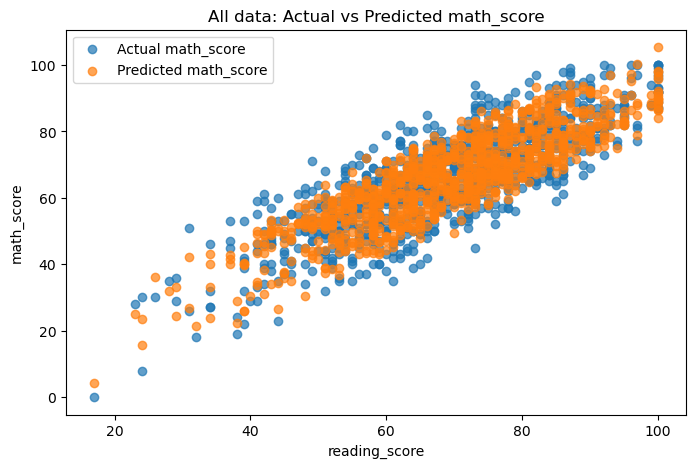

Train R^2 score: 0.8742732380399838
Test R^2 score: 0.8778243107659014


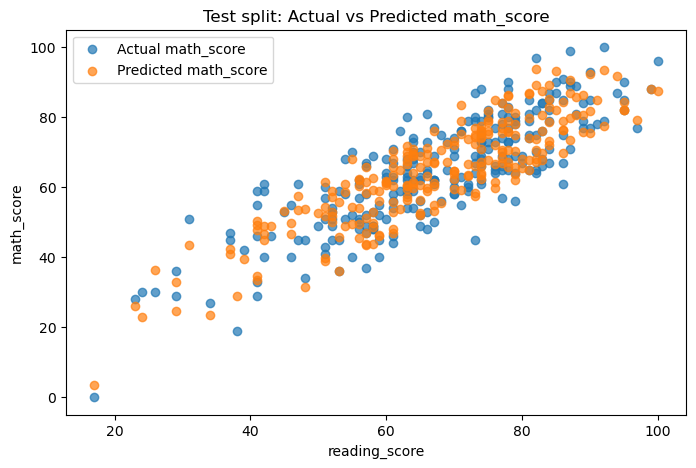

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

df_student_performance = pd.read_csv("data/student_performance.csv")

#Changing column name to remove spaces and make it easier to work with
df_student_performance = df_student_performance.rename(columns={
    "math score": "math_score", 
    "reading score": "reading_score", 
    "writing score": "writing_score", 
    "test preparation course": "test_preparation_course", 
    "race/ethnicity": "race", 
    "parental level of education": "parental_level_of_education", 
    })

#Replacing the race group names to remove the "group " prefix
df_student_performance["race"] = df_student_performance["race"].str.replace("group ", "", regex=False)

# df_student_performance['parental_level_of_education'] = df_student_performance['parental_level_of_education'].replace('some high school', 'high school')
# df_student_performance['parental_level_of_education'].unique()

#Encoding categorical columns
df_encoded = pd.get_dummies(df_student_performance, drop_first=True, dtype=int)
df_student_performance.head()

#Creating Features and samples
X = df_encoded.drop(columns=['math_score'])
y = df_encoded['math_score']

#Fit on all data
model = sk.linear_model.LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
print('R^2 score on all data:', model.score(X, y))

plt.figure(figsize=(8, 5))
plt.scatter(df_student_performance['reading_score'], y, label='Actual math_score', alpha=0.7)
plt.scatter(df_student_performance['reading_score'], y_pred, label='Predicted math_score', alpha=0.7)
plt.xlabel('reading_score')
plt.ylabel('math_score')
plt.title('All data: Actual vs Predicted math_score')
plt.legend()
plt.show()

#Train test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = sk.linear_model.LinearRegression()
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
print('Train R^2 score:', model.score(X_train, y_train))
print('Test R^2 score:', model.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.scatter(X_test['reading_score'], y_test, label='Actual math_score', alpha=0.7)
plt.scatter(X_test['reading_score'], y_test_pred, label='Predicted math_score', alpha=0.7)
plt.xlabel('reading_score')
plt.ylabel('math_score')
plt.title('Test split: Actual vs Predicted math_score')
plt.legend()
plt.show()

7. Repeat the above but this time use `sklearn.preprocessing.OneHotEncoder` to preprocess the data and fit a linear model. Compare the results. 

R^2 score on all the data: 0.8767065867355993


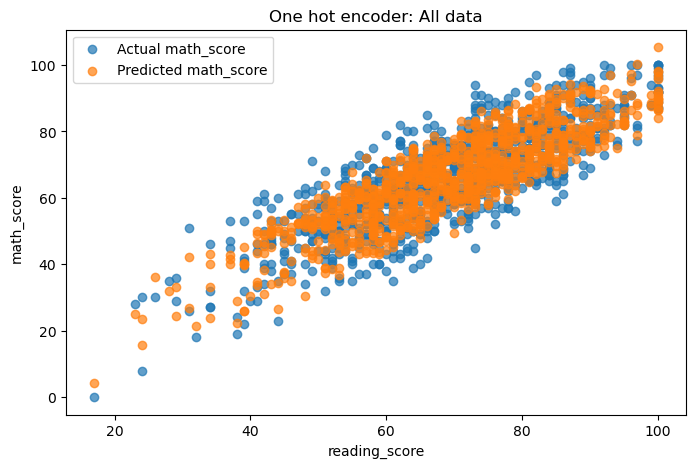

Train R^2 score: 0.8742732380399838
Test R^2 score: 0.8778243107659014


In [85]:
X = df_student_performance.drop(columns=['math_score'])
y = df_student_performance['math_score']

#Identify categorical and numerical columns
categorical_cols = ['gender', 'race', 'parental_level_of_education', 'lunch', 'test_preparation_course']
numerical_cols = ['reading_score', 'writing_score']

#Preprocessor using OneHotEncoder
preprocessor = sk.compose.ColumnTransformer(transformers=[
    ('cat', sk.preprocessing.OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ('num', sk.preprocessing.StandardScaler(), numerical_cols)
])

#Pipeline: preprocessing + linear regression
model = sk.pipeline.make_pipeline(preprocessor, sk.linear_model.LinearRegression())

#Fit on all data
model.fit(X, y)
y_pred = model.predict(X)

print('R^2 score on all the data:', model.score(X, y))
plt.figure(figsize=(8, 5))
plt.scatter(df_student_performance['reading_score'], y, label = 'Actual math_score', alpha=0.7)
plt.scatter(df_student_performance['reading_score'], y_pred, label = 'Predicted math_score', alpha=0.7)
plt.xlabel('reading_score')
plt.ylabel('math_score')
plt.title('One hot encoder: All data')
plt.legend()
plt.show()

# Train/test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = sk.pipeline.make_pipeline(preprocessor, sk.linear_model.LinearRegression())
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

print('Train R^2 score:', model.score(X_train, y_train))
print('Test R^2 score:', model.score(X_test, y_test))

8. Read the section on [hyperparameters and model validation](https://jakevdp.github.io/PythonDataScienceHandbook/05.03-hyperparameters-and-model-validation.html).  Consider the following function given there to make some data.

In [67]:
import numpy as np

def make_data(N, err=1.0, rseed=1):
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

Use this function to make data for 40 points as done in the book. Then repeat the calculations done there to see what happens when you increase the order of the polynomial and plot the validation curve. Note that the import in the book `from sklearn.learning_curve import validation_curve` is out-of-date and should now be `from sklearn.model_selection import validation_curve`.

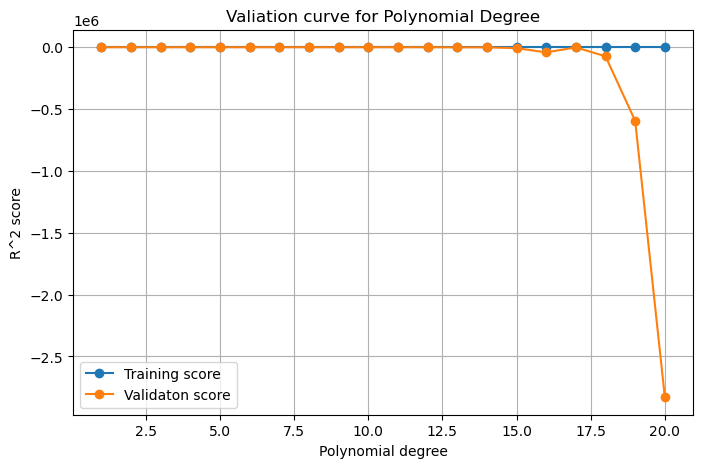

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

#Make data for 40 points
X, y = make_data(40)

#Validation curve for polynomial degree
degree = np.arange(1, 21)

train_score, val_score = sk.model_selection.validation_curve(
    sk.pipeline.make_pipeline(sk.preprocessing.PolynomialFeatures(), sk.linear_model.LinearRegression()),
    X, y,
    param_name = 'polynomialfeatures__degree',
    param_range=degree,
    cv=7,
    scoring='r2'
)

#Mean scored
mean_train_score = np.mean(train_score, axis=1)
mean_val_score = np.mean(val_score, axis=1)

plt.figure(figsize=(8,5))
plt.plot(degree, mean_train_score, 'o-', label='Training score')
plt.plot(degree, mean_val_score, 'o-', label='Validaton score')
plt.xlabel('Polynomial degree')
plt.ylabel('R^2 score')
plt.title('Valiation curve for Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

9. Use the approach from the previous problem to look at our original pendulum data and see what happens with increasing degree of polynomials for this data. In particular plot the validation curve for this data as done in the previous problem.

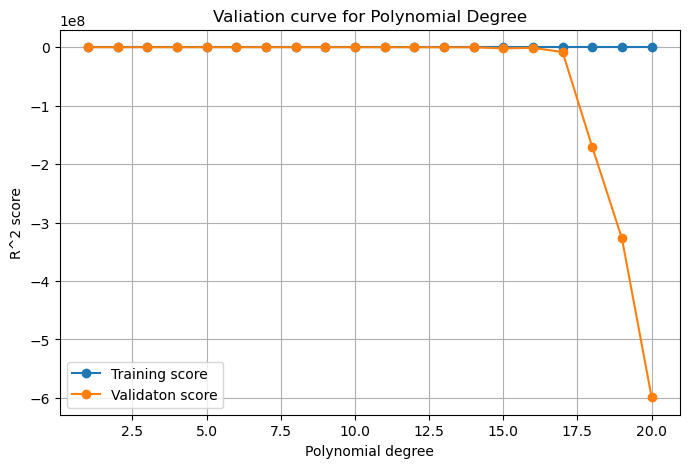

In [76]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

pendulum_data = np.loadtxt("data/pendulum.txt", unpack=True)
X = pendulum_data[0].reshape(-1, 1)
y = pendulum_data[1]

#Validation curve for polynomial degree
degree = np.arange(1, 21)

train_score, val_score = sk.model_selection.validation_curve(
    sk.pipeline.make_pipeline(sk.preprocessing.PolynomialFeatures(), sk.linear_model.LinearRegression()),
    X, y,
    param_name = 'polynomialfeatures__degree',
    param_range=degree,
    cv=7,
    scoring='r2'
)

#Mean scored
mean_train_score = np.mean(train_score, axis=1)
mean_val_score = np.mean(val_score, axis=1)

plt.figure(figsize=(8,5))
plt.plot(degree, mean_train_score, 'o-', label='Training score')
plt.plot(degree, mean_val_score, 'o-', label='Validaton score')
plt.xlabel('Polynomial degree')
plt.ylabel('R^2 score')
plt.title('Valiation curve for Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

10. Look at the `sklearn.datasets.make_blobs` function from the scikit-learn documentation. Use this to make blobs with two and three centers each (see the `centers` keyword argument). Plot the centers for two and three blobs (in separate figures). Use about 50 points for each blob, so 100 for 2 centers and 150 for 3.  You can see examples of this in the [Naive Bayes section](https://jakevdp.github.io/PythonDataScienceHandbook/05.05-naive-bayes.html) of the data science handbook.


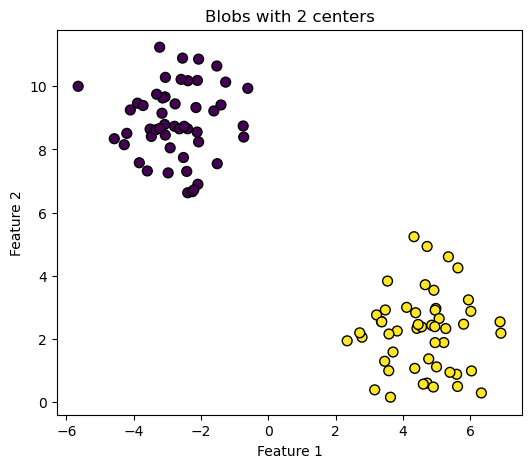

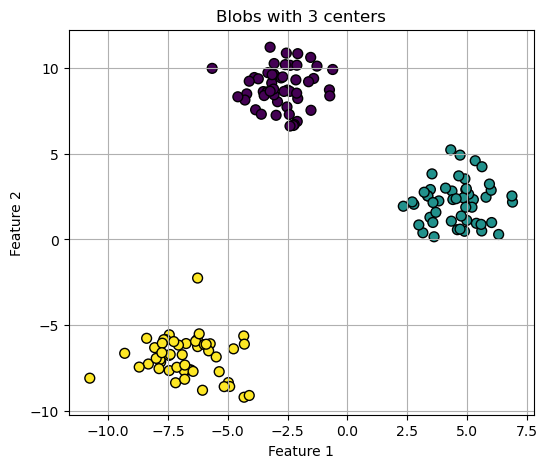

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk

#Two centers: 100 points total
X2, y2 = sk.datasets.make_blobs(n_samples=100, centers=2, cluster_std=1.2, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='viridis', s=50, edgecolors='k')
plt.title('Blobs with 2 centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

#Three centers: 150 points total
X3, y3 = sk.datasets.make_blobs(n_samples=150, centers=3, cluster_std=1.2, random_state=42) 
plt.figure(figsize=(6, 5))
plt.scatter(X3[:, 0], X3[:, 1], c=y3, cmap='viridis', s=50, edgecolors='k')
plt.title('Blobs with 3 centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

11. Use `make_blobs` to create two clusters of points (say 200 points). Use `sklearn.naive_bayes.GaussianNB` to classify the points. Split the data into 80% for training and 20% for testing. After training compute the following for the **training and test data** separately (note that once trained, you can use `model.predict_proba` to get the probabilities for each class).  For example, you should compute the test accuracy and training accuracy and report both.
  
  a. Show a confusion matrix. Hint: `sklearn.metrics.confusion_matrix`
  b. Compute the accuracy, precision, recall, and f1 scores. Hint: see `sklearn.metrics`
  c. Compute the ROC/AUC using the `auc, roc_curve, RocCurveDisplay` from `sklearn.metrics`

Training confusion matrix:
[[77  0]
 [ 0 83]]
Test confusion matrix:
[[23  0]
 [ 0 17]]
Training scores:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Test scores:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Training AUC: 1.0
Test AUC: 1.0


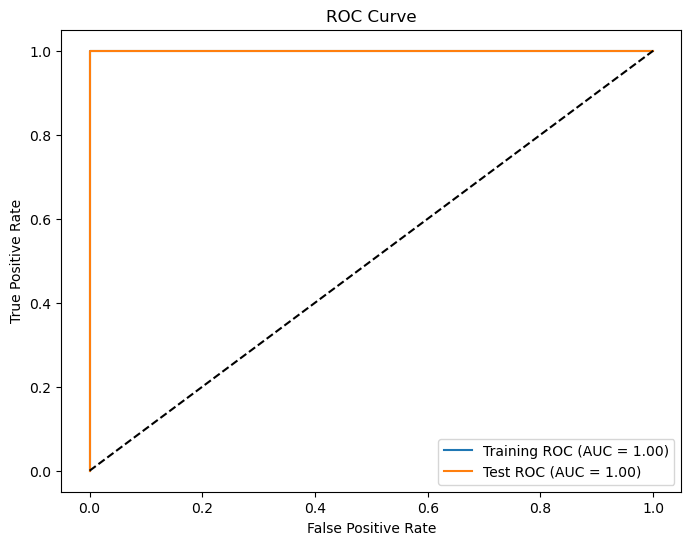

In [82]:
import matplotlib.pyplot as plt
import sklearn as sk


#Create two clusters of points
X, y = sk.datasets.make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=42)

#Split into 80% train and 20% test
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train Gaussian Naive Bayes model
model = sk.naive_bayes.GaussianNB()
model.fit(X_train, y_train)

#Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


#Probabilities for ROC/AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

#Confusion matrix
print('Training confusion matrix:')
print(sk.metrics.confusion_matrix(y_train, y_train_pred))

print('Test confusion matrix:')
print(sk.metrics.confusion_matrix(y_test, y_test_pred))

#Scores
print('Training scores:')
print('Accuracy:', sk.metrics.accuracy_score(y_train, y_train_pred))
print('Precision:', sk.metrics.precision_score(y_train, y_train_pred))
print('Recall:', sk.metrics.recall_score(y_train, y_train_pred))
print('F1 Score:', sk.metrics.f1_score(y_train, y_train_pred))

print('\nTest scores:')
print('Accuracy:', sk.metrics.accuracy_score(y_test, y_test_pred))
print('Precision:', sk.metrics.precision_score(y_test, y_test_pred))
print('Recall:', sk.metrics.recall_score(y_test, y_test_pred))
print('F1 Score:', sk.metrics.f1_score(y_test, y_test_pred))


#ROC/AUC
fpr_train, tpr_train, _ = sk.metrics.roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = sk.metrics.roc_curve(y_test, y_test_prob)

auc_train = sk.metrics.auc(fpr_train, tpr_train)
auc_test = sk.metrics.auc(fpr_test, tpr_test)

print('\nTraining AUC:', auc_train)
print('Test AUC:', auc_test)

#Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label='Training ROC (AUC = {:.2f})'.format(auc_train))
plt.plot(fpr_test, tpr_test, label='Test ROC (AUC = {:.2f})'.format(auc_test))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

12. Experiment with different values of the cluster standard deviation in the `make_blobs` function and see how this affects the scores and results for the previous problem.

Cluster std: 0.5
Training Accuracy: 1.0
Test Accuracy: 1.0
Training Precision: 1.0
Test Precision: 1.0
Test recall: 1.0
Test F1 1.0


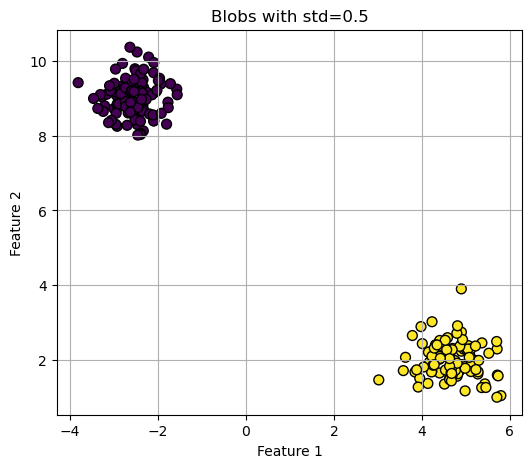

Cluster std: 1.0
Training Accuracy: 1.0
Test Accuracy: 1.0
Training Precision: 1.0
Test Precision: 1.0
Test recall: 1.0
Test F1 1.0


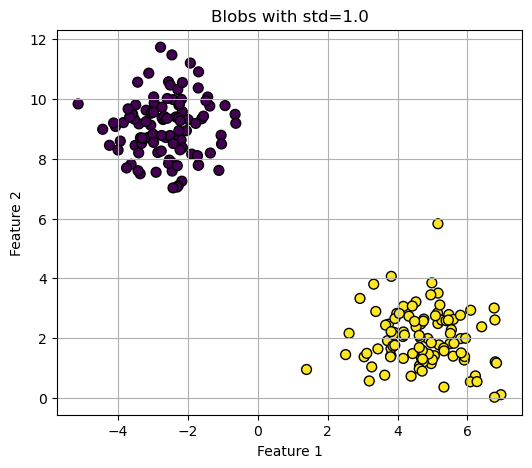

Cluster std: 1.5
Training Accuracy: 1.0
Test Accuracy: 1.0
Training Precision: 1.0
Test Precision: 1.0
Test recall: 1.0
Test F1 1.0


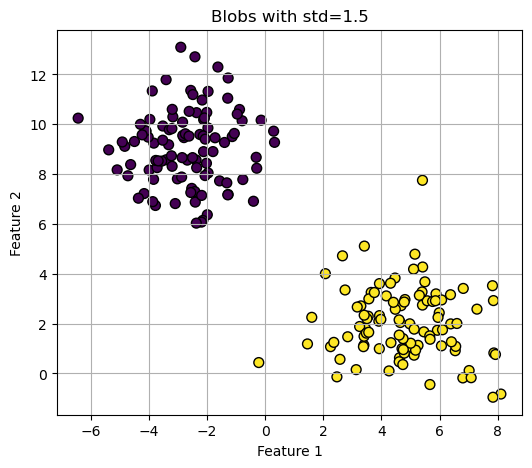

Cluster std: 2.0
Training Accuracy: 1.0
Test Accuracy: 1.0
Training Precision: 1.0
Test Precision: 1.0
Test recall: 1.0
Test F1 1.0


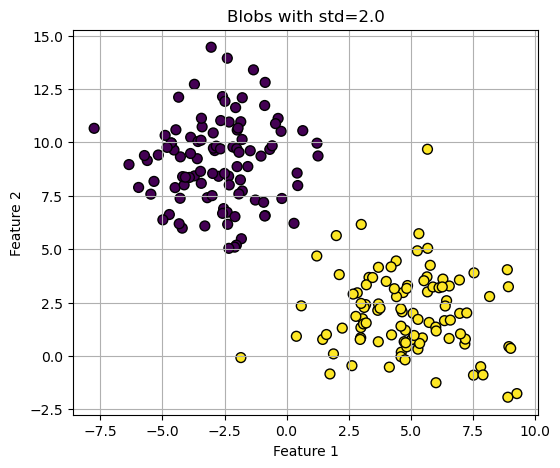

In [84]:
import matplotlib.pyplot as plt
import numpy as np

cluster_stds = [0.5, 1.0, 1.5, 2.0]

for std in cluster_stds:
    print(f"Cluster std: {std}")

    #Create data
    X, y = sk.datasets.make_blobs(
        n_samples=200, 
        centers=2, 
        cluster_std=std, 
        random_state=42
        )
    
    #Split data
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    #Train GaussianNB
    model = sk.naive_bayes.GaussianNB()
    model.fit(X_train, y_train)

    #Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Print Scores
    print('Training Accuracy:', sk.metrics.accuracy_score(y_train, y_train_pred))
    print('Test Accuracy:', sk.metrics.accuracy_score(y_test, y_test_pred))
    print('Training Precision:', sk.metrics.precision_score(y_train, y_train_pred))
    print('Test Precision:', sk.metrics.precision_score(y_test, y_test_pred))
    print('Test recall:', sk.metrics.recall_score(y_test, y_test_pred))
    print('Test F1', sk.metrics.f1_score(y_test, y_test_pred))

    #Plot blobs
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
    plt.title(f'Blobs with std={std}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()

13. Use `sklearn.linear_model.LogisticRegression` to repeat the problem 8 above and see how it performs.

Training confusion matrix:
[[77  0]
 [ 0 83]]
Test confusion matrix:
[[23  0]
 [ 0 17]]

Training scores:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Test scores:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Training AUC: 1.0
Test AUC: 1.0


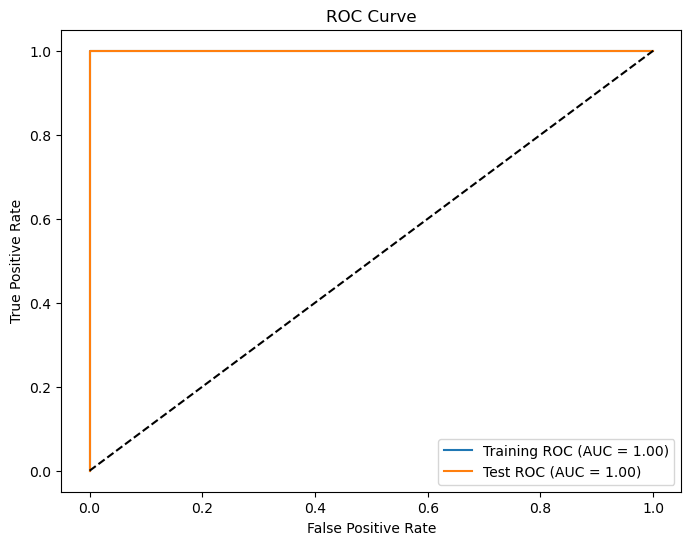

In [83]:
import matplotlib.pyplot as plt
import sklearn as sk

#Create two clusters of points
X, y = sk.datasets.make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=42)

#Split into 80% train and 20% test
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train Logistic Regression model
model = sk.linear_model.LogisticRegression()
model.fit(X_train, y_train)

#Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#Probabilities for ROC/AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

#Confusion matrix
print('Training confusion matrix:')
print(sk.metrics.confusion_matrix(y_train, y_train_pred))

print('Test confusion matrix:')
print(sk.metrics.confusion_matrix(y_test, y_test_pred))

#Scores
print('\nTraining scores:')
print('Accuracy:', sk.metrics.accuracy_score(y_train, y_train_pred))
print('Precision:', sk.metrics.precision_score(y_train, y_train_pred))
print('Recall:', sk.metrics.recall_score(y_train, y_train_pred))
print('F1 Score:', sk.metrics.f1_score(y_train, y_train_pred))

print('\nTest scores:')
print('Accuracy:', sk.metrics.accuracy_score(y_test, y_test_pred))
print('Precision:', sk.metrics.precision_score(y_test, y_test_pred))
print('Recall:', sk.metrics.recall_score(y_test, y_test_pred))
print('F1 Score:', sk.metrics.f1_score(y_test, y_test_pred))

#ROC/AUC
fpr_train, tpr_train, _ = sk.metrics.roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = sk.metrics.roc_curve(y_test, y_test_prob)

auc_train = sk.metrics.auc(fpr_train, tpr_train)
auc_test = sk.metrics.auc(fpr_test, tpr_test)

print('\nTraining AUC:', auc_train)
print('Test AUC:', auc_test)    

#Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label='Training ROC (AUC = {:.2f})'.format(auc_train))
plt.plot(fpr_test, tpr_test, label='Test ROC (AUC = {:.2f})'.format(auc_test))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()